# EDA Yoochoose Dataset

Zakres notebooka:
- tylko surowe pliki `clicks`, `buys`, `test`
- bez preprocessingu, splitów i feature engineeringu
- cel: rozpoznać typy danych, strukturę rekordów i różnice między plikami

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

parent_dir = str(Path().resolve().parents[0])

sys.path.insert(0, parent_dir)


In [2]:
from src.common.paths import get_project_root

raw_dir = get_project_root() / "data" / "raw"
raw_dir

WindowsPath('C:/UWR AI/SEMESTR II/ADM/adm-project-tgnn/data/raw')

In [3]:
files = {
    "clicks": raw_dir / "yoochoose-clicks.dat",
    "buys": raw_dir / "yoochoose-buys.dat",
    "test": raw_dir / "yoochoose-test.dat",
}

display(pd.read_csv(files["clicks"], header=None, nrows=1))
display(pd.read_csv(files["buys"], header=None, nrows=1))
display(pd.read_csv(files["test"], header=None, nrows=1))

,0,1,2,3
0,1,2014-04-07T10:51:09.277Z,214536502,0


,0,1,2,3,4
0,420374,2014-04-06T18:44:58.314Z,214537888,12462,1


,0,1,2,3
0,5,2014-04-07T17:13:46.713Z,214530776,0


## Wczytywanie danych

In [4]:
clicks_dtypes = {
    'session_id': 'int32',
    'item_id': 'int32',
    'category': 'str'
}

clicks_raw_df = pd.read_csv(
    files["clicks"], 
    header=None, 
    names=["session_id", "timestamp", "item_id", "category"],
    dtype=clicks_dtypes,
    parse_dates=['timestamp']
)

buys_raw_df = pd.read_csv(
    files["buys"], 
    header=None, 
    names=["session_id", "timestamp", "item_id", "price", "quantity"],
    dtype={'session_id': 'int32', 'item_id': 'int32', 'price': 'int32', 'quantity': 'int32'},
    parse_dates=['timestamp']
)

test_raw_df = pd.read_csv(
    files["test"],
    header=None,
    names=["session_id", "timestamp", "item_id", "category"],
    dtype=clicks_dtypes,
    parse_dates=['timestamp']
)

## Jakość danych

In [5]:
for name, df in [
    ("clicks_raw_df", clicks_raw_df),
    ("buys_raw_df", buys_raw_df),
    ("test_raw_df", test_raw_df),
]:
    print(f"Brakujące wartości w {name} (suma): {df.isnull().sum().sum()}")
    missing = df.isnull().sum()
    if missing.any():
        print(missing[missing > 0])
    else:
        print("  Brak brakujących wartości w poszczególnych kolumnach.")
    print()

Brakujące wartości w clicks_raw_df (suma): 0
  Brak brakujących wartości w poszczególnych kolumnach.

Brakujące wartości w buys_raw_df (suma): 0
  Brak brakujących wartości w poszczególnych kolumnach.

Brakujące wartości w test_raw_df (suma): 0
  Brak brakujących wartości w poszczególnych kolumnach.



## Statystyki ogólne

In [6]:
print(f"Liczba kliknięć: {len(clicks_raw_df)}")
print(f"Liczba unikalnych sesji (clicks): {clicks_raw_df['session_id'].nunique()}")
print(f"Liczba unikalnych przedmiotów (clicks): {clicks_raw_df['item_id'].nunique()}")
print(f"Liczba transakcji zakupu: {len(buys_raw_df)}")
print(f"Liczba sesji z zakupem: {buys_raw_df['session_id'].nunique()}")

conversion_rate = buys_raw_df['session_id'].nunique() / clicks_raw_df['session_id'].nunique()
print(f"Procent sesji zakończonych zakupem: {conversion_rate * 100:.2f}%")

Liczba kliknięć: 33003944
Liczba unikalnych sesji (clicks): 9249729
Liczba unikalnych przedmiotów (clicks): 52739
Liczba transakcji zakupu: 1150753
Liczba sesji z zakupem: 509696
Procent sesji zakończonych zakupem: 5.51%


## Oś czasu i podpróbkowanie

Chronologiczny podział i subsampling sesji (pełne sesje, bez rozcinania) — pod planowany pipeline 70/15/15 i frakcje 1/32–1/64.

Zakres czasowy (clicks):
  od 2014-04-01 03:00:00.124000+00:00 do 2014-09-30 02:59:59.430000+00:00
Zakres czasowy (buys):
  od 2014-04-01 03:05:31.743000+00:00 do 2014-09-30 02:35:12.859000+00:00
Zakres czasowy (test):
  od 2014-04-01 03:00:08.250000+00:00 do 2014-09-30 02:59:23.866000+00:00


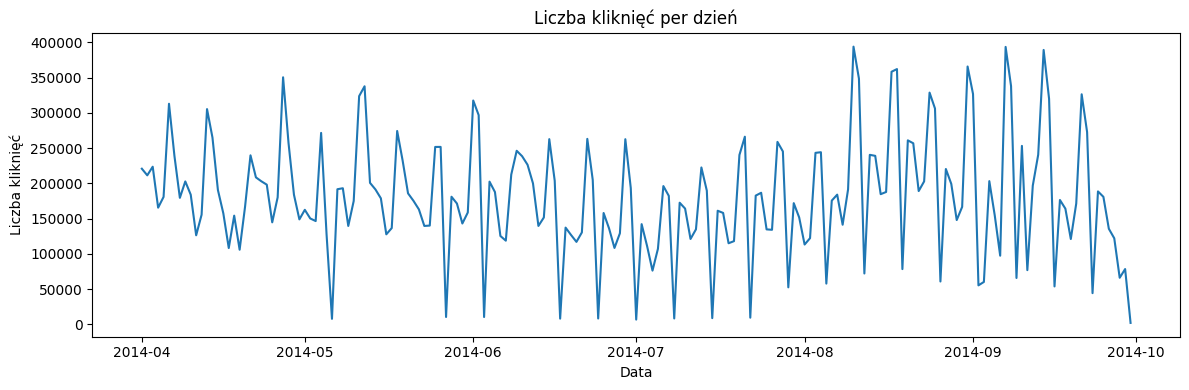


Propozycja splitu chronologicznego (po kliknięciach, train/val/test wewnętrzny):
  train: do 2014-08-11 12:36:33.426000+00:00
  val:   2014-08-11 12:36:33.426000+00:00 — 2014-09-02 00:59:42.480000+00:00
  test:  po 2014-09-02 00:59:42.480000+00:00
  (osobno: yoochoose-test.dat to sesje testowe challenge)

Podpróbkowanie chronologiczne (pełne sesje, od najstarszych):

Frakcja sesji 1.0000 (~9,249,729 sesji):
  interakcji: 33,003,944
  unikalnych itemów: 52,739
  śr. długość sesji: 3.57

Frakcja sesji 0.0312 (~289,054 sesji):
  interakcji: 1,137,399
  unikalnych itemów: 21,490
  śr. długość sesji: 3.93

Frakcja sesji 0.0156 (~144,527 sesji):
  interakcji: 563,002
  unikalnych itemów: 17,301
  śr. długość sesji: 3.90


In [7]:
print("Zakres czasowy (clicks):")
print(f"  od {clicks_raw_df['timestamp'].min()} do {clicks_raw_df['timestamp'].max()}")
print("Zakres czasowy (buys):")
print(f"  od {buys_raw_df['timestamp'].min()} do {buys_raw_df['timestamp'].max()}")
print("Zakres czasowy (test):")
print(f"  od {test_raw_df['timestamp'].min()} do {test_raw_df['timestamp'].max()}")

clicks_daily = clicks_raw_df.groupby(clicks_raw_df['timestamp'].dt.date).size()

plt.figure(figsize=(12, 4))
clicks_daily.plot()
plt.title('Liczba kliknięć per dzień')
plt.xlabel('Data')
plt.ylabel('Liczba kliknięć')
plt.tight_layout()
plt.show()

clicks_sorted_time = clicks_raw_df['timestamp'].sort_values()
n_events = len(clicks_sorted_time)
t_train_end = clicks_sorted_time.iloc[int(n_events * 0.70) - 1]
t_val_end = clicks_sorted_time.iloc[int(n_events * 0.85) - 1]

print("\nPropozycja splitu chronologicznego (po kliknięciach, train/val/test wewnętrzny):")
print(f"  train: do {t_train_end}")
print(f"  val:   {t_train_end} — {t_val_end}")
print(f"  test:  po {t_val_end}")
print("  (osobno: yoochoose-test.dat to sesje testowe challenge)")

session_start = clicks_raw_df.groupby('session_id')['timestamp'].min().sort_values()
n_sessions_total = len(session_start)

print("\nPodpróbkowanie chronologiczne (pełne sesje, od najstarszych):")
for frac in [1.0, 1 / 32, 1 / 64]:
    n_keep = max(1, int(n_sessions_total * frac))
    kept_sessions = session_start.iloc[:n_keep].index
    sub = clicks_raw_df[clicks_raw_df['session_id'].isin(kept_sessions)]
    sub_lengths = sub.groupby('session_id').size()

    print(f"\nFrakcja sesji {frac:.4f} (~{n_keep:,} sesji):")
    print(f"  interakcji: {len(sub):,}")
    print(f"  unikalnych itemów: {sub['item_id'].nunique():,}")
    print(f"  śr. długość sesji: {sub_lengths.mean():.2f}")

## Przykłady next-item

Skala zadania samonadzorowanego: z prefiksu sesji przewidujemy następny kliknięty produkt.

In [8]:
session_lengths = clicks_raw_df.groupby('session_id').size()

n_sessions = len(session_lengths)
n_single = (session_lengths == 1).sum()
n_pairs = (session_lengths - 1).clip(lower=0).sum()

print(f"Sesji łącznie: {n_sessions:,}")
print(
    f"Sesji jednoklikowych (brak pary next-item): {n_single:,} "
    f"({n_single / n_sessions * 100:.2f}%)"
)
print(f"Łączna liczba par treningowych (next-item): {int(n_pairs):,}")

print("\nUnikalne itemy w sesji:")
print(
    clicks_raw_df.groupby('session_id')['item_id']
    .nunique()
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
)

clicks_ordered = clicks_raw_df.sort_values(['session_id', 'timestamp'])
prev_item = clicks_ordered.groupby('session_id')['item_id'].shift(1)
repeat_clicks = (clicks_ordered['item_id'] == prev_item) & prev_item.notna()

print(
    f"\nKliknięć powtarzających poprzedni item w sesji: "
    f"{repeat_clicks.sum():,} ({repeat_clicks.mean() * 100:.2f}%)"
)

target_item = clicks_ordered.groupby('session_id')['item_id'].shift(-1)
valid_targets = target_item.notna()
target_is_repeat = (target_item == clicks_ordered['item_id']) & valid_targets

print(
    f"Target next-item = ten sam item co bieżący krok: "
    f"{target_is_repeat.sum():,} ({target_is_repeat.sum() / valid_targets.sum() * 100:.2f}%)"
)

Sesji łącznie: 9,249,729
Sesji jednoklikowych (brak pary next-item): 1,259,711 (13.62%)
Łączna liczba par treningowych (next-item): 23,754,215

Unikalne itemy w sesji:
count    9.249729e+06
mean     2.877444e+00
std      2.977013e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
90%      5.000000e+00
99%      1.400000e+01
max      2.000000e+02
Name: item_id, dtype: float64

Kliknięć powtarzających poprzedni item w sesji: 4,032,400 (12.22%)
Target next-item = ten sam item co bieżący krok: 4,032,400 (16.98%)


## Przejścia sesyjne i kaskadowość

Czy lokalne przejścia (item → next_item) zniekształcają globalną popularność produktów?

In [9]:
clicks_ordered = clicks_raw_df.sort_values(['session_id', 'timestamp'])
clicks_ordered = clicks_ordered.assign(
    next_item=clicks_ordered.groupby('session_id')['item_id'].shift(-1)
)
transitions = clicks_ordered.dropna(subset=['next_item'])

transition_counts = transitions.groupby(['item_id', 'next_item']).size()
print("Top 15 przejść (item → next_item) w sesjach:")
display(transition_counts.sort_values(ascending=False).head(15).to_frame('count'))

global_next = clicks_raw_df['item_id'].value_counts(normalize=True)
top_sources = transitions['item_id'].value_counts().head(5).index

bias_rows = []
for src in top_sources:
    cond = transitions.loc[transitions['item_id'] == src, 'next_item'].value_counts(normalize=True)
    top_next = cond.index[0]
    global_prob = global_next.get(top_next, 0.0)
    bias_rows.append({
        'source_item': src,
        'top_next': top_next,
        'P(next|source)': cond.iloc[0],
        'P(next) globalnie': global_prob,
        'lift': cond.iloc[0] / global_prob if global_prob > 0 else float('inf'),
    })

bias_df = pd.DataFrame(bias_rows)
print("\nKaskadowość: najczęstszy następnik vs popularność globalna (top 5 źródeł):")
display(bias_df)

Top 15 przejść (item → next_item) w sesjach:


,,count
item_id,next_item,
643078800,643078800.0,71090
214853094,214853094.0,23475
214684093,214684093.0,17222
214853420,214853420.0,15041
214834880,214834880.0,14546
214826610,214826610.0,14352
214829878,214829878.0,13979
214835017,214835747.0,13275
214829747,214829747.0,13118



Kaskadowość: najczęstszy następnik vs popularność globalna (top 5 źródeł):


,source_item,top_next,P(next|source),P(next) globalnie,lift
0,214829878,214829878.0,0.157448,0.003439,45.788077
1,643078800,643078800.0,0.827321,0.004467,185.219280
2,214853094,214853094.0,0.293853,0.003808,77.160424
3,214853420,214853420.0,0.264123,0.002377,111.119384
4,214826610,214826610.0,0.260057,0.002112,123.122813


## Analiza sesji

In [10]:
session_lengths = clicks_raw_df.groupby('session_id').size()

print("Statystyki długości sesji (liczba kliknięć):")
print(session_lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

Statystyki długości sesji (liczba kliknięć):
count    9.249729e+06
mean     3.568098e+00
std      3.787520e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      4.000000e+00
90%      7.000000e+00
99%      1.800000e+01
max      2.000000e+02
dtype: float64


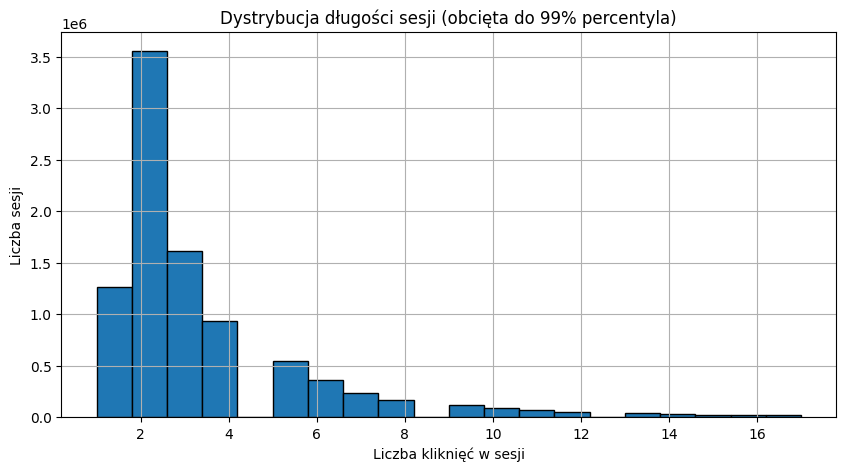

In [11]:
plt.figure(figsize=(10, 5))
session_lengths[session_lengths < session_lengths.quantile(0.99)].hist(bins = 20, edgecolor='black')
plt.title('Dystrybucja długości sesji (obcięta do 99% percentyla)')
plt.xlabel('Liczba kliknięć w sesji')
plt.ylabel('Liczba sesji')
plt.show()

In [12]:
session_times = clicks_raw_df.groupby('session_id')['timestamp'].agg(['min', 'max'])
session_durations = (session_times['max'] - session_times['min']).dt.total_seconds() / 60.0

print("Statystyki czasu trwania sesji (w minutach):")
session_durations.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

Statystyki czasu trwania sesji (w minutach):


count    9.249729e+06
mean     6.360556e+00
std      1.261075e+01
min      0.000000e+00
25%      5.369000e-01
50%      2.132317e+00
75%      6.402200e+00
90%      1.654619e+01
99%      5.883665e+01
max      4.098967e+03
dtype: float64

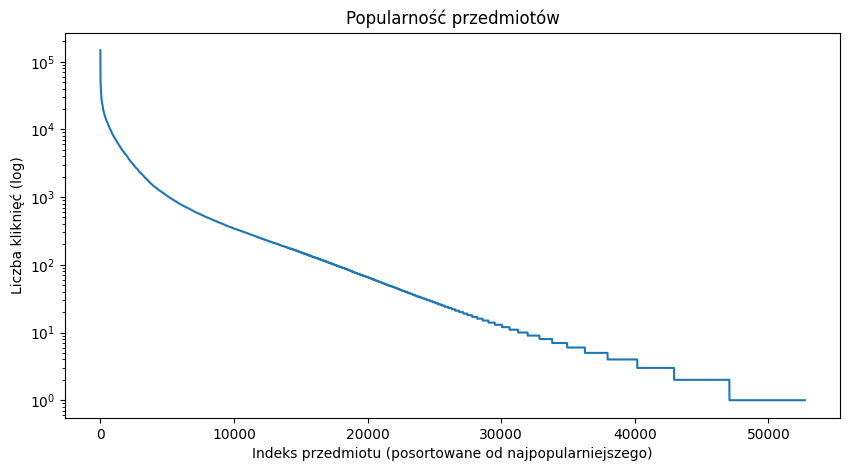

Top 1% najpopularniejszych przedmiotów generuje 34.95% wszystkich kliknięć.


In [13]:
item_counts = clicks_raw_df['item_id'].value_counts()

plt.figure(figsize=(10, 5))
plt.plot(item_counts.values)
plt.yscale('log')
plt.title('Popularność przedmiotów')
plt.xlabel('Indeks przedmiotu (posortowane od najpopularniejszego)')
plt.ylabel('Liczba kliknięć (log)')
plt.show()

print(f"Top 1% najpopularniejszych przedmiotów generuje {item_counts.iloc[:int(len(item_counts)*0.01)].sum() / len(clicks_raw_df) * 100:.2f}% wszystkich kliknięć.")

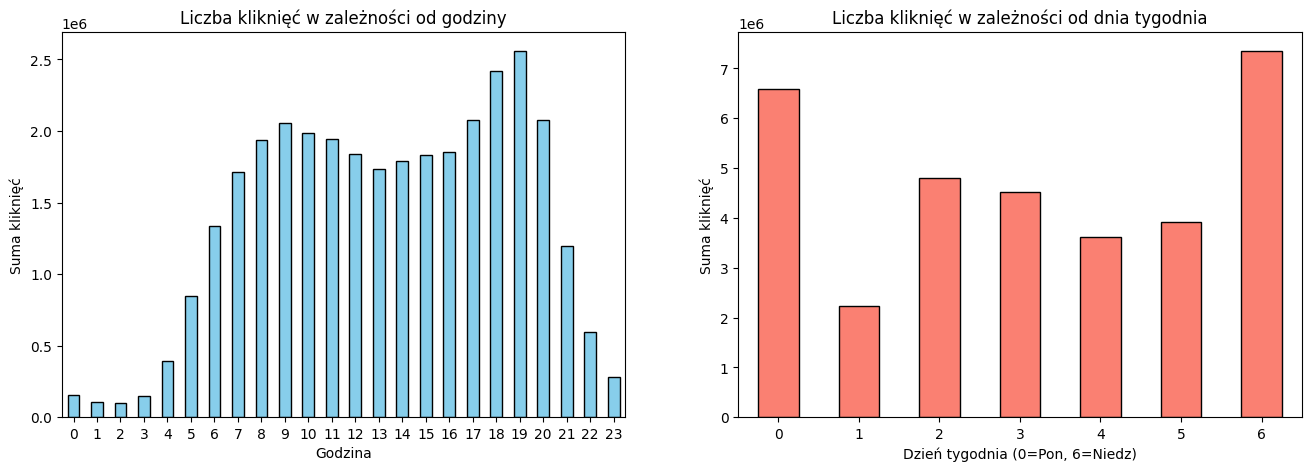

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

clicks_raw_df.groupby(clicks_raw_df['timestamp'].dt.hour).size().plot(
    kind='bar', ax=ax[0], color='skyblue', edgecolor='black'
)
ax[0].set_title('Liczba kliknięć w zależności od godziny')
ax[0].tick_params(axis='x', rotation=0)
ax[0].set_xlabel('Godzina')
ax[0].set_ylabel('Suma kliknięć')

clicks_raw_df.groupby(clicks_raw_df['timestamp'].dt.dayofweek).size().plot(
    kind='bar', ax=ax[1], color='salmon', edgecolor='black'
)
ax[1].set_title('Liczba kliknięć w zależności od dnia tygodnia')
ax[1].tick_params(axis='x', rotation=0)
ax[1].set_xlabel('Dzień tygodnia (0=Pon, 6=Niedz)')
ax[1].set_ylabel('Suma kliknięć')

plt.show()

## Category — typy i spójność

Klasyfikacja wartości `category` pod cechy krawędzi w TGN (one-hot / embedding).

In [15]:
def classify_category(value: str) -> str:
    if pd.isna(value):
        return 'missing'
    if value == 'S':
        return 'special_offer'
    if value == '0':
        return 'no_category'
    if value in {str(i) for i in range(1, 13)}:
        return 'product_category'
    if value.isdigit() and len(value) >= 8:
        return 'brand_context'
    return 'other'


cat = clicks_raw_df['category'].astype(str)
cat_type = cat.map(classify_category)

print("Przykładowe unikalne wartości w kolumnie category:")
display(clicks_raw_df['category'].unique()[:20])

print(f"\nBrakujące wartości (NaN) w category: {clicks_raw_df['category'].isna().sum()}")
print(f"Puste stringi w category: {(clicks_raw_df['category'] == '').sum()}")

print("\nTypy wartości category:")
display(cat_type.value_counts())

print("\nUdział 'S' i '0':")
for label in ['special_offer', 'no_category']:
    share = (cat_type == label).mean() * 100
    print(f"  {label}: {share:.2f}%")

print("\nTop 10 najczęstszych surowych wartości category:")
display(clicks_raw_df['category'].value_counts().head(10))

item_cat_nunique = clicks_raw_df.groupby('item_id')['category'].nunique()
inconsistent_items = (item_cat_nunique > 1).sum()
print(
    f"\nItemy z więcej niż jedną category: {inconsistent_items:,} "
    f"({inconsistent_items / len(item_cat_nunique) * 100:.4f}%)"
)
if inconsistent_items > 0:
    print("Rozkład liczby category per item (tylko niespójne):")
    display(item_cat_nunique[item_cat_nunique > 1].describe())

Przykładowe unikalne wartości w kolumnie category:


<StringArray>
[         '0',          'S',          '4',          '7',          '3',
          '2',          '1', '2089286907',          '6',          '5',
         '10',          '9', '2089422131',         '11', '2089538467',
 '2089134472', '2088954951', '2089529540', '2088904854',         '12']
Length: 20, dtype: str


Brakujące wartości (NaN) w category: 0
Puste stringi w category: 0

Typy wartości category:


category
no_category         16337653
special_offer       10769610
product_category     5820377
brand_context          76022
other                    282
Name: count, dtype: int64


Udział 'S' i '0':
  special_offer: 32.63%
  no_category: 49.50%

Top 10 najczęstszych surowych wartości category:


category
0    16337653
S    10769610
1     1671754
2     1292249
3      789713
4      480569
5      471923
6      414696
7      389910
9      105282
Name: count, dtype: int64


Itemy z więcej niż jedną category: 35,228 (66.7969%)
Rozkład liczby category per item (tylko niespójne):


count    35228.000000
mean         2.344697
std          0.610311
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: category, dtype: float64

## Zakupy (buys) vs kliknięcia

Czy zakupy da się potraktować jako osobny typ zdarzenia lub silniejszy sygnał w sesji?

In [16]:
print("Rozkład price:")
display(buys_raw_df['price'].describe(percentiles=[0.5, 0.9, 0.99]))

print("\nRozkład quantity:")
display(buys_raw_df['quantity'].describe(percentiles=[0.5, 0.9, 0.99]))

buy_session_ids = buys_raw_df['session_id'].unique()
clicks_in_buy_sessions = clicks_raw_df[clicks_raw_df['session_id'].isin(buy_session_ids)]

first_buy_ts = buys_raw_df.groupby('session_id')['timestamp'].min().rename('first_buy_ts')
clicks_before_buy = clicks_in_buy_sessions.merge(first_buy_ts, on='session_id')
clicks_before_buy = clicks_before_buy[
    clicks_before_buy['timestamp'] < clicks_before_buy['first_buy_ts']
]

print(f"\nKliknięć przed pierwszym zakupem (sesje z buy): {len(clicks_before_buy):,}")
print(
    f"Śr. liczba kliknięć przed zakupem: "
    f"{clicks_before_buy.groupby('session_id').size().mean():.2f}"
)

click_counts = (
    clicks_raw_df.groupby(['session_id', 'item_id'])
    .size()
    .rename('click_count')
    .reset_index()
)
buys_with_clicks = buys_raw_df.merge(click_counts, on=['session_id', 'item_id'], how='left')
buys_with_clicks['was_clicked'] = buys_with_clicks['click_count'].fillna(0) > 0

print(
    f"\nZakupów dotyczących itemu wcześniej klikniętego w sesji: "
    f"{buys_with_clicks['was_clicked'].mean() * 100:.2f}%"
)

last_click = (
    clicks_raw_df.sort_values('timestamp')
    .groupby('session_id')
    .tail(1)[['session_id', 'item_id']]
    .rename(columns={'item_id': 'last_click_item'})
)
buy_last_match = buys_raw_df.merge(last_click, on='session_id', how='left')
buy_last_match['buy_is_last_click'] = (
    buy_last_match['item_id'] == buy_last_match['last_click_item']
)

print(
    f"Zakup = ostatni kliknięty item w sesji: "
    f"{buy_last_match['buy_is_last_click'].mean() * 100:.2f}%"
)

Rozkład price:


count    1.150753e+06
mean     1.423527e+03
std      4.651549e+03
min      0.000000e+00
50%      0.000000e+00
90%      3.141000e+03
99%      2.083900e+04
max      3.349980e+05
Name: price, dtype: float64


Rozkład quantity:


count    1.150753e+06
mean     6.460865e-01
std      1.144520e+00
min      0.000000e+00
50%      0.000000e+00
90%      1.000000e+00
99%      5.000000e+00
max      3.000000e+01
Name: quantity, dtype: float64


Kliknięć przed pierwszym zakupem (sesje z buy): 3,187,550
Śr. liczba kliknięć przed zakupem: 6.25

Zakupów dotyczących itemu wcześniej klikniętego w sesji: 100.00%
Zakup = ostatni kliknięty item w sesji: 34.61%


In [17]:
clicks_sorted = clicks_raw_df.sort_values(['item_id', 'timestamp'])
item_time_diff = clicks_sorted.groupby('item_id')['timestamp'].diff().dt.total_seconds()

print("Statystyki czasu (w sek) między kolejnymi interakcjami tego samego produktu:")
print(item_time_diff.describe(percentiles=[0.5, 0.75, 0.90]))

Statystyki czasu (w sek) między kolejnymi interakcjami tego samego produktu:
count    3.295120e+07
mean     1.449999e+04
std      1.620478e+05
min      0.000000e+00
50%      1.704420e+02
75%      1.525774e+03
90%      1.224037e+04
max      1.531297e+07
Name: timestamp, dtype: float64


In [18]:
clicks_sorted_session = clicks_raw_df.sort_values(['session_id', 'timestamp'])
session_time_diff = clicks_sorted_session.groupby('session_id')['timestamp'].diff().dt.total_seconds()

print("Rozkład opóźnień między kliknięciami wewnątrz sesji:")
print(session_time_diff.describe(percentiles=[0.1, 0.25, 0.5]))
# Ile interakcji ma dokładnie ten sam timestamp (0.0 sekund różnicy)?
print(f"Procent interakcji z delta_t == 0: {(session_time_diff == 0).mean() * 100:.2f}%")

Rozkład opóźnień między kliknięciami wewnątrz sesji:
count    2.375422e+07
mean     1.486054e+02
std      3.261748e+02
min      0.000000e+00
10%      1.024800e+01
25%      2.681900e+01
50%      5.850700e+01
max      3.599995e+03
Name: timestamp, dtype: float64
Procent interakcji z delta_t == 0: 0.00%


In [19]:
# Ile unikalnych sesji połączonych jest z danym przedmiotem
item_degree = clicks_raw_df.groupby('item_id')['session_id'].nunique()
print("Statystyki stopnia węzłów (Item Degree Distribution):")
print(item_degree.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))

Statystyki stopnia węzłów (Item Degree Distribution):
count    52739.000000
mean       504.665921
std       2190.251030
min          1.000000
50%         18.000000
75%        168.000000
90%        775.000000
99%      10185.200000
max      92332.000000
Name: session_id, dtype: float64


## Test — indukcja i cold start

Porównanie `yoochoose-test.dat` z trainem pod kątem sesji, czasu i nowych itemów (ewaluacja indukcyjna TGN).

In [20]:
train_items = set(clicks_raw_df['item_id'].unique())
test_items = set(test_raw_df['item_id'].unique())
cold_start_items = test_items - train_items

print(f"Liczba sesji (test): {test_raw_df['session_id'].nunique():,}")
print(f"Liczba sesji (train clicks): {clicks_raw_df['session_id'].nunique():,}")
print(f"Liczba unikalnych przedmiotów w teście: {len(test_items):,}")
print(
    f"Cold start itemów: {len(cold_start_items):,} "
    f"({len(cold_start_items) / len(test_items) * 100:.2f}%)"
)

test_session_lengths = test_raw_df.groupby('session_id').size()
train_session_lengths = clicks_raw_df.groupby('session_id').size()

print("\nDługość sesji — train vs test:")
print("train:")
print(train_session_lengths.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))
print("test:")
print(test_session_lengths.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))

print("\nZakres czasowy test vs train:")
print(f"  train: {clicks_raw_df['timestamp'].min()} — {clicks_raw_df['timestamp'].max()}")
print(f"  test:  {test_raw_df['timestamp'].min()} — {test_raw_df['timestamp'].max()}")

test_session_items = test_raw_df.groupby('session_id')['item_id'].apply(set)
full_cold_sessions = test_session_items.apply(lambda items: len(items - train_items) == len(items)).sum()
partial_cold_sessions = test_session_items.apply(
    lambda items: 0 < len(items - train_items) < len(items)
).sum()
known_only_sessions = test_session_items.apply(lambda items: len(items - train_items) == 0).sum()

print("\nSesje testowe wg widoczności itemów:")
print(f"  pełny cold start (wszystkie itemy nowe): {full_cold_sessions:,}")
print(f"  częściowy cold start: {partial_cold_sessions:,}")
print(f"  tylko itemy znane z train: {known_only_sessions:,}")

Liczba sesji (test): 2,312,432
Liczba sesji (train clicks): 9,249,729
Liczba unikalnych przedmiotów w teście: 42,155
Cold start itemów: 1,548 (3.67%)

Długość sesji — train vs test:
train:
count    9.249729e+06
mean     3.568098e+00
std      3.787520e+00
min      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
90%      7.000000e+00
99%      1.800000e+01
max      2.000000e+02
dtype: float64
test:
count    2.312432e+06
mean     3.568447e+00
std      3.806272e+00
min      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
90%      7.000000e+00
99%      1.800000e+01
max      2.000000e+02
dtype: float64

Zakres czasowy test vs train:
  train: 2014-04-01 03:00:00.124000+00:00 — 2014-09-30 02:59:59.430000+00:00
  test:  2014-04-01 03:00:08.250000+00:00 — 2014-09-30 02:59:23.866000+00:00

Sesje testowe wg widoczności itemów:
  pełny cold start (wszystkie itemy nowe): 438
  częściowy cold start: 1,029
  tylko itemy znane z train: 2,310,965


In [21]:
# Sprawdzenie spójności ID
buy_sessions = set(buys_raw_df['session_id'].unique())
click_sessions = set(clicks_raw_df['session_id'].unique())

orphan_buy_sessions = buy_sessions - click_sessions
print(f"Liczba sesji zakupowych bez odpowiadających im kliknięć: {len(orphan_buy_sessions)}")

Liczba sesji zakupowych bez odpowiadających im kliknięć: 0


## Pod grafy i TGN

Struktura pod SR-GNN (graf sesyjny), graf dwudzielny sesja–item i sygnał czasowy Δt.

In [22]:
session_lengths = clicks_raw_df.groupby('session_id').size()
n_single = (session_lengths == 1).sum()
print(
    f"Sesje 1-klikowe (graf SR-GNN bez krawędzi): {n_single:,} "
    f"({n_single / len(session_lengths) * 100:.2f}%)"
)

dup_cols = ['session_id', 'item_id', 'timestamp']
n_dup = clicks_raw_df.duplicated(subset=dup_cols).sum()
print(f"Duplikaty (session_id, item_id, timestamp): {n_dup:,}")

clicks_ordered = clicks_raw_df.sort_values(['session_id', 'timestamp'])
dt_ms = clicks_ordered.groupby('session_id')['timestamp'].diff().dt.total_seconds() * 1000

print("\nΔt między kliknięciami w sesji [ms]:")
print(dt_ms.describe(percentiles=[0.5, 0.75, 0.9, 0.99]))
print(f"Udział Δt == 0 ms: {(dt_ms == 0).mean() * 100:.4f}%")

n_sessions = clicks_raw_df['session_id'].nunique()
n_items = clicks_raw_df['item_id'].nunique()
print(f"\nWęzły grafu dwudzielnego (TGN): {n_sessions + n_items:,}")
print(f"  sesje: {n_sessions:,}")
print(f"  itemy: {n_items:,}")
print(f"Krawędzie (kliknięcia): {len(clicks_raw_df):,}")

item_degree = clicks_raw_df.groupby('item_id')['session_id'].nunique()
item_clicks = clicks_raw_df['item_id'].value_counts()
print(f"\nKorelacja item_degree (sesje) vs liczba kliknięć: {item_degree.corr(item_clicks):.4f}")

Sesje 1-klikowe (graf SR-GNN bez krawędzi): 1,259,711 (13.62%)
Duplikaty (session_id, item_id, timestamp): 69

Δt między kliknięciami w sesji [ms]:
count    2.375422e+07
mean     1.486054e+05
std      3.261748e+05
min      0.000000e+00
50%      5.850700e+04
75%      1.297340e+05
90%      2.995390e+05
99%      1.879542e+06
max      3.599995e+06
Name: timestamp, dtype: float64
Udział Δt == 0 ms: 0.0034%

Węzły grafu dwudzielnego (TGN): 9,302,468
  sesje: 9,249,729
  itemy: 52,739
Krawędzie (kliknięcia): 33,003,944

Korelacja item_degree (sesje) vs liczba kliknięć: 0.9930


## Przygotowanie ewaluacji

Skala katalogu i siła prostego baseline'u popularnościowego (HR@20 / MRR@20).

In [23]:
catalog_size = clicks_raw_df['item_id'].nunique()
print(f"Rozmiar katalogu (unikalne itemy w train clicks): {catalog_size:,}")

global_pop = clicks_raw_df['item_id'].value_counts(normalize=True)
top20_items = set(global_pop.head(20).index)

clicks_ordered = clicks_raw_df.sort_values(['session_id', 'timestamp'])
targets = clicks_ordered.groupby('session_id')['item_id'].shift(-1).dropna()

in_top20 = targets.isin(top20_items).mean() * 100
print(f"\nTarget next-item w globalnym TOP-20 popularności: {in_top20:.2f}%")

pop_baseline_recall20 = global_pop.head(20).sum()
print(
    f"Górny limit Recall@20 dla baseline 'zawsze TOP-20 globalne': "
    f"{pop_baseline_recall20 * 100:.2f}%"
)

top1_item = global_pop.index[0]
hit_top1 = (targets == top1_item).mean() * 100
print(f"Target = najpopularniejszy item globalnie: {hit_top1:.4f}%")

print("\nRozkład częstotliwości itemów (kliknięcia):")
print(global_pop.describe(percentiles=[0.5, 0.9, 0.99]))

Rozmiar katalogu (unikalne itemy w train clicks): 52,739

Target next-item w globalnym TOP-20 popularności: 3.63%
Górny limit Recall@20 dla baseline 'zawsze TOP-20 globalne': 4.11%
Target = najpopularniejszy item globalnie: 0.3350%

Rozkład częstotliwości itemów (kliknięcia):
count    5.273900e+04
mean     1.896130e-05
std      8.514351e-05
min      3.029941e-08
50%      6.665870e-07
90%      2.908743e-05
99%      3.824228e-04
max      4.466709e-03
Name: proportion, dtype: float64


## Wnioski z EDA i rekomendacje preprocessingu

Poniższe podsumowanie opiera się na outputach powyższych komórek (pełny train: ~33M kliknięć, ~9.25M sesji, 52 739 itemów).

### 1. Jakość i skala danych

| Obserwacja | Wartość | Wniosek |
|------------|---------|----------|
| Braki (NaN) w clicks / buys / test | 0 | Brak imputacji |
| Sesje zakupowe bez kliknięć | 0 | `buys` spójne z `clicks` |
| Konwersja (sesja z buy) | 5.51% | Zakupy jako osobny sygnał — opcjonalnie w v2 |
| Zakres czasowy (clicks, buys, test) | kwi–wrz 2014, nakładające się | `test.dat` ≠ „przyszłość”; to **inne sesje**, nie późniejszy okres |

**Preprocessing:** wczytać trzy pliki bez uzupełniania braków; metadane (`meta.json`) zapisać ze skalą i datami splitu.

---

### 2. Podpróbkowanie i split

| Ustawienie | Liczby z EDA |
|------------|--------------|
| Pełny zbiór | 33 003 944 kliknięć, 9 249 729 sesji, 52 739 itemów |
| Subsample **1/32** (chronologicznie, pełne sesje) | ~1 137 399 interakcji, ~289 054 sesji, 21 490 itemów, śr. dł. sesji 3.93 |
| Subsample **1/64** | ~563 002 interakcji, ~144 527 sesji, 17 301 itemów |
| Split 70/15/15 (po czasie zdarzeń) | train → `2014-08-11 12:36:33 UTC`; val do `2014-09-02 00:59:42`; test wewn. po tej dacie |

**Preprocessing:**
- **Dev / trening:** subsample **1/32** po **pełnych sesjach** od najstarszych (jak w komórce powyżej).
- **Split wewnętrzny:** chronologiczny 70/15/15, ale **przypisać całe sesje** do bucketa według czasu pierwszego kliknięcia (nie ciąć sesji między train/val).
- **Ewaluacja challenge:** osobno `yoochoose-test.dat` (2.31M sesji, rozkład długości identyczny z trainem).

---

### 3. Next-item i filtrowanie sesji

| Metryka | Wartość | Wniosek |
|---------|---------|----------|
| Sesje 1-klikowe | 1 259 711 (13.62%) | Brak par treningowych next-item |
| Par next-item (łącznie) | 23 754 215 | Główny zbiór uczący |
| Mediana unikalnych itemów / sesja | 2 | Krótkie sesje; `max_len=20` wystarczy (p99 = 18 kliknięć) |
| Powtórzenie poprzedniego itemu w sesji | 12.22% kliknięć | Silne self-loopy |
| Target = ten sam item co bieżący krok | 16.98% par | Duży udział repeatów jako targetu |
| Duplikaty `(session_id, item_id, timestamp)` | 69 | Usunąć przy czyszczeniu |

**Preprocessing:**
1. Usunąć 69 duplikatów.
2. **Wykluczyć sesje 1-klikowe** z generowania par next-item (można zostawić w grafie TGN jako izolowane węzły sesji).
3. **Opcja (do testu A/B):** złączyć kolejne powtórzenia tego samego itemu `A,A,A→A` przed budową grafu — zmniejszy bias self-transition (top przejścia to głównie `item→item`).
4. Nie filtrować itemów po min. freq na start (utrata cold startu).

---

### 4. Kaskadowość i popularność

- Top przejścia to głównie **self-loopy** (np. item `643078800 → 643078800`, lift ~185).
- Top 1% itemów generuje **34.95%** kliknięć.
- Korelacja `item_degree` (sesje) vs liczba kliknięć: **0.993**.
- Tylko **3.63%** targetów next-item trafia w globalne TOP-20; górny limit Recall@20 dla baseline popularnościowego: **~4.11%**.

**Preprocessing / trening:**
- Negative sampling: **ważony popularnością** (`freq^0.75`), nie uniform.
- W raporcie obowiązkowy baseline **POP@20** — zadanie jest trudne poza surową popularnością.

---

### 5. Category (cecha krawędzi TGN)

| Typ | Udział |
|-----|--------|
| `no_category` (`"0"`) | 49.50% |
| `special_offer` (`"S"`) | 32.63% |
| `product_category` (1–12) | ~17.6% |
| `brand_context` (długie ID) | ~0.23% |
| Itemy z >1 category | **35 228 (66.8%)** | śr. 2.3 category/item |

**Preprocessing:**
1. Mapowanie do bucketów (`classify_category` z komórki powyżej).
2. Dla każdego `item_id`: **mode** z `category` (66.8% itemów jest niespójnych).
3. Encoding: one-hot 5 bucketów lub `nn.Embedding` (dim ~16) jako `edge_attr` w TGN.

---

### 6. Zakupy (buys) — faza opcjonalna

- 100% zakupionych itemów było wcześniej klikniętych w sesji.
- Tylko **34.61%** zakupów = ostatni klik w sesji.
- Śr. **6.25** kliknięć przed pierwszym zakupem w sesjach z buy.
- `price` / `quantity`: mediana 0 (dużo zer w danych).

**Preprocessing:** w **v1** uczyć next-item tylko z `clicks`. `buys` zostawić na v2 (drugi typ krawędzi w TGN lub osobna metryka). Jeśli użyte: `log1p(price)`, `quantity` jako int.

---

### 7. Timestamp i graf TGN

| Metryka | Wartość |
|---------|----------|
| Mediana Δt w sesji | ~58.5 s (~58 507 ms) |
| Δt == 0 | 0.0034% (ms) |
| Węzły grafu dwudzielnego | 9 302 468 (sesje + itemy) |
| Krawędzie | 33 003 944 |
| Sesje 1-klikowe (brak krawędzi SR-GNN) | 13.62% |

**Preprocessing:**
1. `t_sec = (timestamp - t_min_train).total_seconds()` (float64).
2. Sortowanie: `(session_id, timestamp, original_row_index)` — stabilność przy remisach.
3. Eksport `TemporalData`: `src=session_idx`, `dst=item_idx`, `t`, `edge_attr`; globalnie posortowane po `t`.
4. Dla SR-GNN/TAGNN: krawędzie między kolejnymi kliknięciami w sesji (po ewentualnej deduplikacji repeatów).

---

### 8. Test i cold start

| Metryka | Wartość |
|---------|----------|
| Itemy w teście | 42 155 |
| Cold start itemów (poza train) | 1 548 (**3.67%**) |
| Sesje: pełny cold start | 438 |
| Sesje: częściowy cold start | 1 029 |
| Sesje: tylko znane itemy | 2 310 965 |

**Preprocessing:**
- Słownik itemów z **train `clicks` only** + token `<UNK>` dla OOV.
- Raportować metryki osobno: all / known items / cold start.
- Indukcja TGN: nowe sesje testowe, pamięć inicjalizowana od zera.

---

### 9. Proponowany pipeline (`src/preprocessing/`)

```
load_raw
  → subsample_sessions(fraction=1/32)     # dev
  → assign_chronological_split(70/15/15)  # całe sesje
  → clean (dedup, opcj. merge repeats)
  → remap_ids (session, item + UNK)
  → normalize_timestamps
  → encode_category (bucket + mode per item)
  → build_next_item_pairs (len >= 2)
  → export:
       events.parquet      # TGN (źródło prawdy)
       sequences.pkl       # GRU4Rec
       session_graphs.pkl  # TAGNN / SR-GNN
       challenge_test/     # yoochoose-test.dat
```

**Priorytet implementacji:** subsample → split → remap → pary next-item → `events.parquet` → eksporty pochodne.

---

### 10. Otwarte decyzje

1. **Deduplikacja repeatów** w sesji — zostawić surowe dane vs złączyć `A,A→A` (wpływ na kaskadowość i SR-GNN).
2. **Target w val/test** — ostatni klik sesji vs sliding window (ustalić jedną regułę dla wszystkich modeli).
3. **Subsample finalny** — 1/32 na dev, pełny zbiór vs większa frakcja na końcowe eksperymenty.
4. **Integracja buys** — v1 bez buys vs multigraf w TGN.